In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, auc
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv("../dataset/Kamil_kg_V/heart_preprocess.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301717 entries, 0 to 301716
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        301717 non-null  int64  
 1   HeartDisease      301717 non-null  int64  
 2   BMI               301717 non-null  float64
 3   Smoking           301717 non-null  int64  
 4   AlcoholDrinking   301717 non-null  int64  
 5   Stroke            301717 non-null  int64  
 6   PhysicalHealth    301717 non-null  float64
 7   MentalHealth      301717 non-null  float64
 8   DiffWalking       301717 non-null  int64  
 9   Sex               301717 non-null  int64  
 10  AgeCategory       278365 non-null  float64
 11  Diabetic          292385 non-null  float64
 12  PhysicalActivity  301717 non-null  int64  
 13  GenHealth         301717 non-null  int64  
 14  SleepTime         301717 non-null  float64
 15  Asthma            301717 non-null  int64  
 16  KidneyDisease     30

In [4]:
df.describe()

,Unnamed: 0,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
count,301717.000000,301717.000000,301717.000000,301717.000000,301717.000000,301717.000000,301717.000000,301717.000000,301717.000000,301717.000000,278365.000000,292385.00000,301717.000000,301717.000000,301717.000000,301717.000000,301717.000000,301717.000000
mean,157330.290640,0.090353,28.441970,0.422267,0.071527,0.039984,3.572298,4.121475,0.147009,1.529208,7.048803,0.13882,0.763669,2.446372,7.084559,0.141361,0.039030,0.097084
std,92603.871127,0.286687,6.468134,0.493921,0.257704,0.195923,8.140656,8.128288,0.354115,0.499147,3.344463,0.34576,0.424828,1.047515,1.467122,0.348394,0.193667,0.296073
min,0.000000,0.000000,12.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.00000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,76538.000000,0.000000,24.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.000000,0.00000,1.000000,2.000000,6.000000,0.000000,0.000000,0.000000
50%,155954.000000,0.000000,27.410000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,8.000000,0.00000,1.000000,2.000000,7.000000,0.000000,0.000000,0.000000
75%,237304.000000,0.000000,31.650000,1.000000,0.000000,0.000000,2.000000,4.000000,0.000000,2.000000,10.000000,0.00000,1.000000,3.000000,8.000000,0.000000,0.000000,0.000000
max,319794.000000,1.000000,94.850000,1.000000,1.000000,1.000000,30.000000,30.000000,1.000000,2.000000,12.000000,1.00000,1.000000,5.000000,24.000000,1.000000,1.000000,1.000000


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['HeartDisease'].value_counts()

HeartDisease
0    274456
1     27261
Name: count, dtype: int64

In [7]:
df['HeartDisease'] = np.where(df['HeartDisease'] == 0, 0, 1)

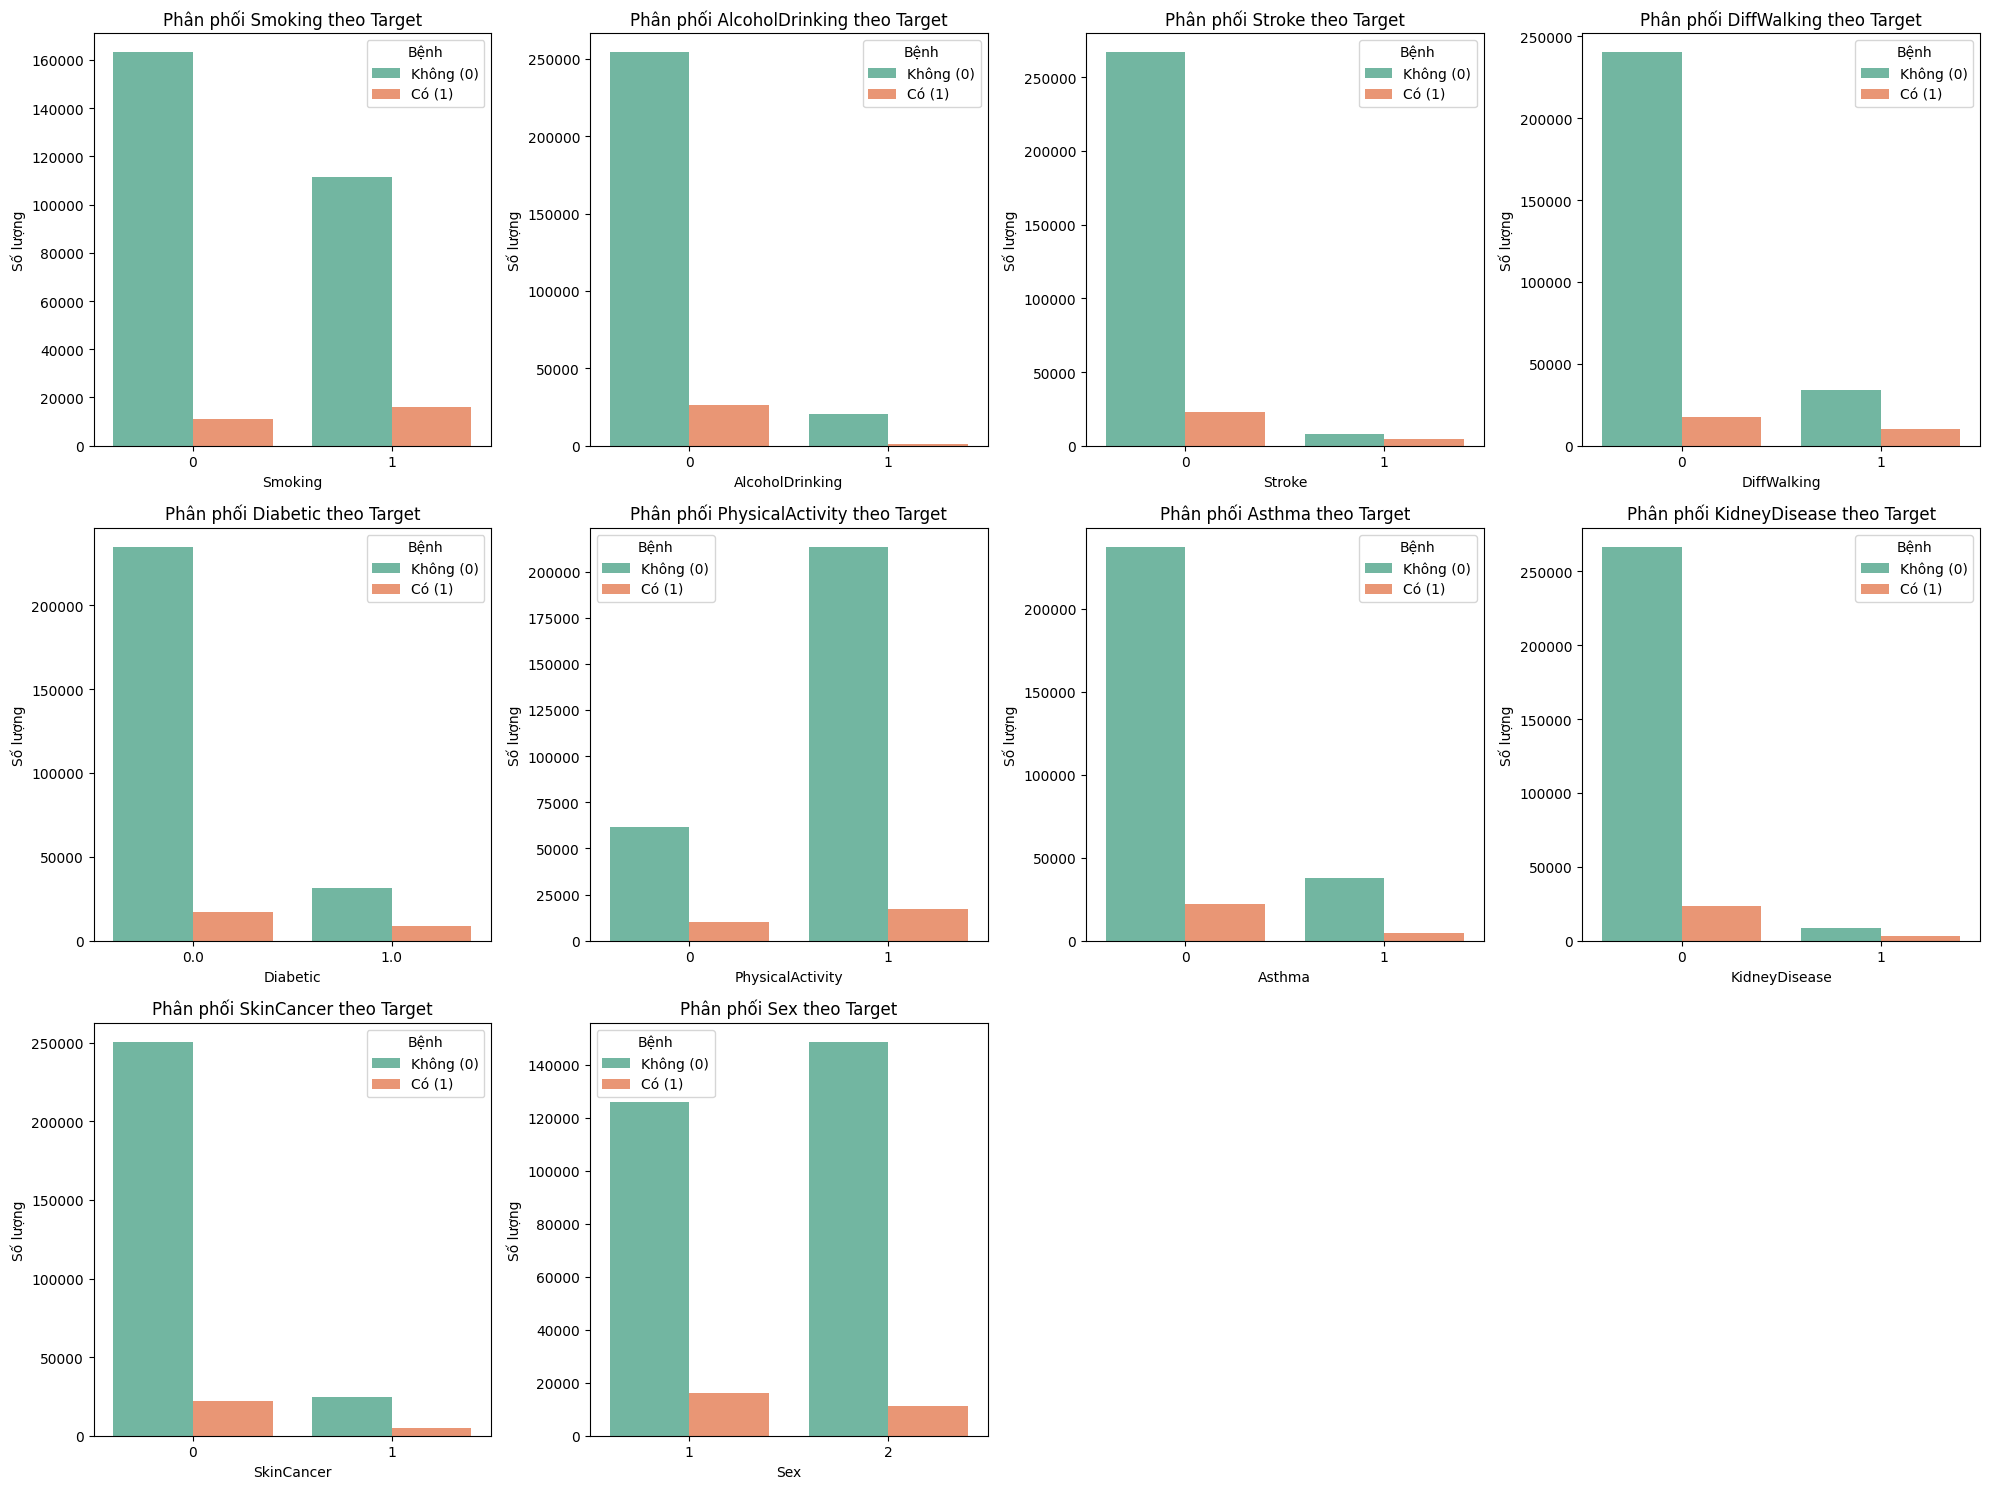

In [8]:
categorical_features = ["Smoking",
    "AlcoholDrinking",
    "Stroke",
    "DiffWalking",
    "Diabetic",
    "PhysicalActivity",
    "Asthma",
    "KidneyDisease",
    "SkinCancer",
    "Sex"]

plt.figure(figsize=(20, 15))

for i, col in enumerate(categorical_features, 1):
    plt.subplot(3, 4, i)
    sns.countplot(x=col, hue='HeartDisease', data=df, palette='Set2')
    plt.title(f'Phân phối {col} theo Target')
    plt.xlabel(col)
    plt.ylabel('Số lượng')
    plt.legend(title='Bệnh', labels=['Không (0)', 'Có (1)'])

plt.tight_layout()
plt.show()

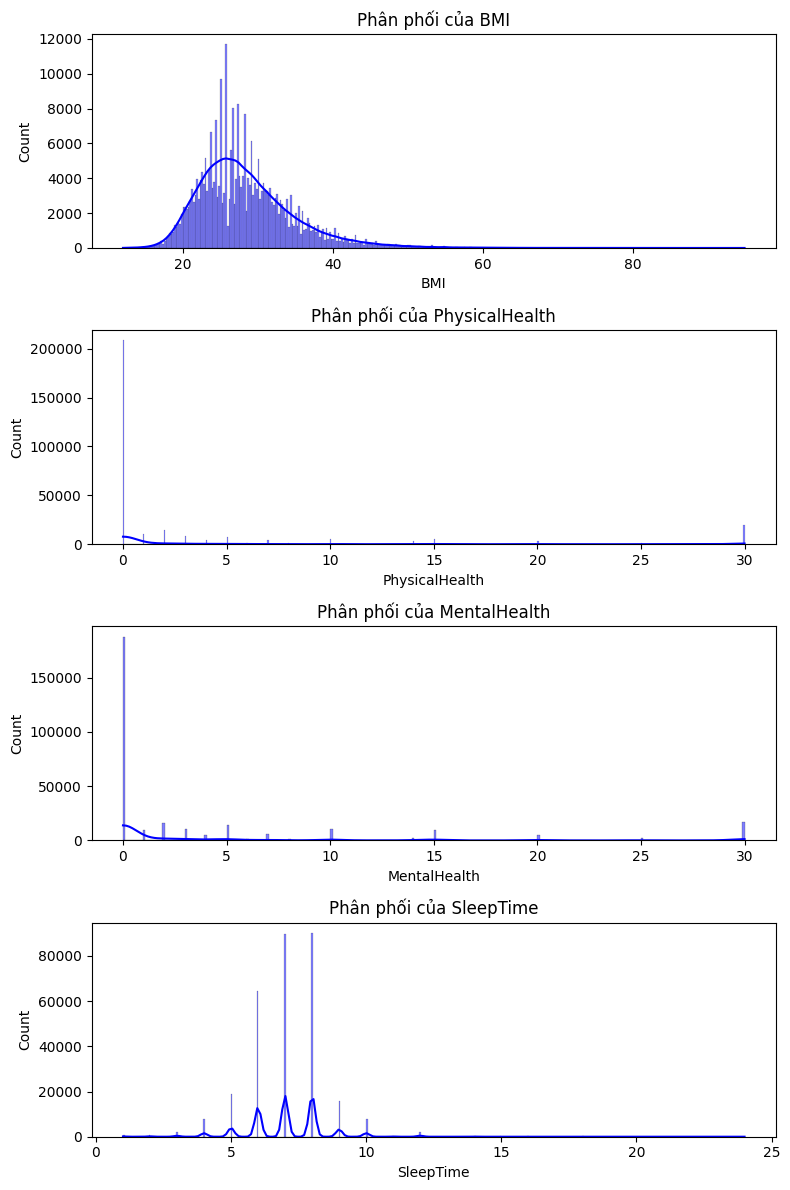

In [9]:
continuous_features = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']

plt.figure(figsize=(15, 12))
for i, col in enumerate(continuous_features):
    plt.subplot(len(continuous_features), 2, 2*i + 1)
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(f'Phân phối của {col}')
    

plt.tight_layout()
plt.show()

In [14]:
df.drop('Unnamed: 0',axis=1,inplace=True)

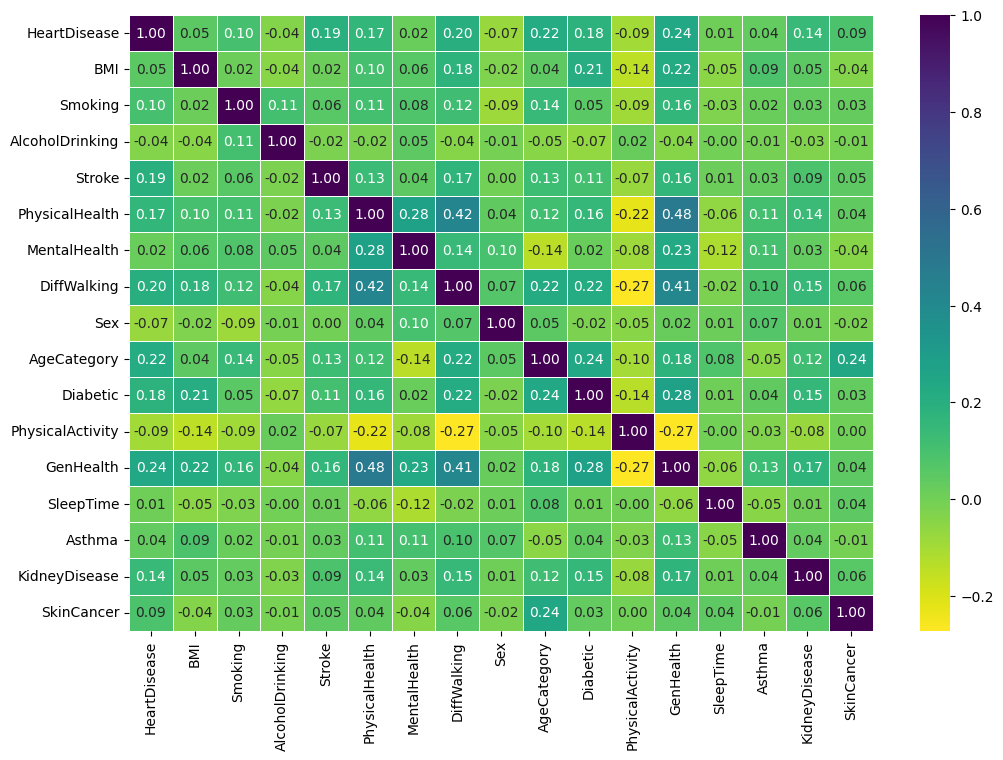

In [15]:
corr_matrix = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, linewidth=0.5, fmt='.2f', cmap='viridis_r');